In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

In [3]:
using ColorSchemes

In [4]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Setup

In [5]:
function make_scale_func(xs)
    mi, mx = extrema(xs)
    d = mx - mi
    if d < eps()
        nothing
    else
        x -> (x - mi) / d
    end
end
function centres_to_edges_closed(xs)
    N = length(xs)
    xs2 = zeros(N+1)
    for i in 1:N-1
        xs2[i+1] = (xs[i] + xs[i+1]) / 2
    end
    xs2[1] = xs[1]
    xs2[end] = xs[end]
    xs2
end

centres_to_edges_closed (generic function with 1 method)

In [ ]:
function get_rel_col_20(xx)
    rels = xx ./ sum(xx)

    sp = sortperm(rels)
    
    c = ColorSchemes.tab20[sp[1]]
    s = rels[sp[1]]
    for i in sp[2:end]
        newc = ColorSchemes.tab20[i]

        s += rels[i]
        c = get(cgrad([c, newc]), rels[i] / s)
    end

    c
end

get_rel_col_20 (generic function with 1 method)

# Looking at data

In [305]:
# f = jldopen("./data1_better.jld2")
f = jldopen("./data1_qndf.jld2")
df = f["df"];
fmd = f["metadata"];

In [306]:
N = fmd.N
M = fmd.M
sN = fmd.sN

1000

In [309]:
df.means = [map(df.sol_us[i]) do u reshape(mean(u; dims=2), N+M) end for i in 1:nrow(df)];

In [310]:
df.totbioms = [map(mm) do mu sum(mu[1:N]) end for mm in df.means];

In [311]:
df.fTs = last.(df.sol_ts);
collect(zip(df.fTs, df.maxresids))

8-element Vector{Tuple{Float64, Float64}}:
 (1.0e8, 1.204778499186432e-10)
 (1.0e8, 1.1407763622628408e-10)
 (4864.154422749759, 0.021548585502582682)
 (1.0e8, 4.243815965310205e-9)
 (1.0e8, 3.6658776014775185e-10)
 (1.0e8, 1.9478818558127386e-10)
 (1.0e8, 4.132054032268684e-9)
 (1.0e8, 8.035794252236883e-11)

In [ ]:
df.fTs = last.(df.sol_ts);
collect(zip(df.fTs, df.maxresids))

8-element Vector{Tuple{Float64, Float64}}:
 (9.123948084574586e7, 4.042294481365616e-7)
 (8.528634435793445e7, 7.120970835217122e-8)
 (4.28824357768576e7, 1.0802262728759615e-7)
 (1.0e8, 0.006171129220983396)
 (1.0e8, 8.011576263511344e-9)
 (1.0e8, 5.706119715620517e-9)
 (1.0e8, 4.516387264175137e-11)
 (1.0e8, 0.00011080929813722662)

## Showing coarsening

In [352]:
r = df[4,:];
@show r.ps;

totb_mat = hcat(map(r.sol_us) do x sum(x[1:N,:], dims=1)[:] end...);
sprel_totb_mat = totb_mat ./ maximum(totb_mat; dims=1);

r.ps = 0.13894954943731377


### Black and white

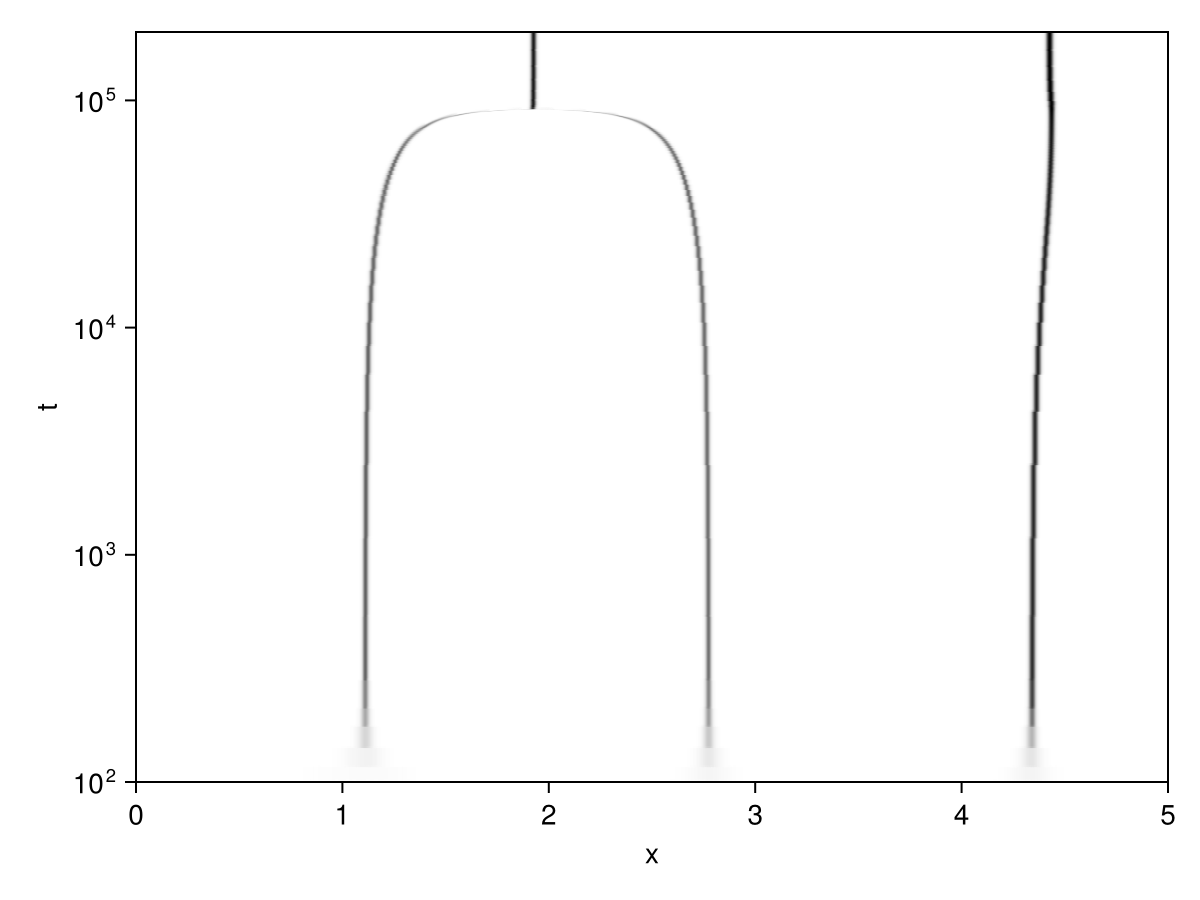

In [134]:
tedges = centres_to_edges_closed(r.sol_ts);
xedges = 0:fmd.dx:fmd.L

fig = Figure()
ax = Axis(fig[1,1];
    xlabel="x",
    ylabel="t",
    yscale=log10
)

heatmap!(ax, xedges, tedges, totb_mat;
    colormap=ColorSchemes.Greys,
)

# ylims!(ax, 1e0, tedges[end])
ylims!(ax, 1e2, 2e5)

# display(GLMakie.Screen(), fig)
fig

### Adding colours

In [353]:
cols_mat = hcat(map(r.sol_us) do u
    [get_rel_col_20(u[1:N,x]) for x in 1:size(u, 2)]
end...);

maxb = maximum(totb_mat)
scaled_cols_mat = map(zip(cols_mat, totb_mat)) do (c, b)
    alphacolor(c, b / maxb)
end;
sprel_scaled_cols_mat = map(zip(cols_mat, sprel_totb_mat)) do (c, b)
    alphacolor(c, b)
end;

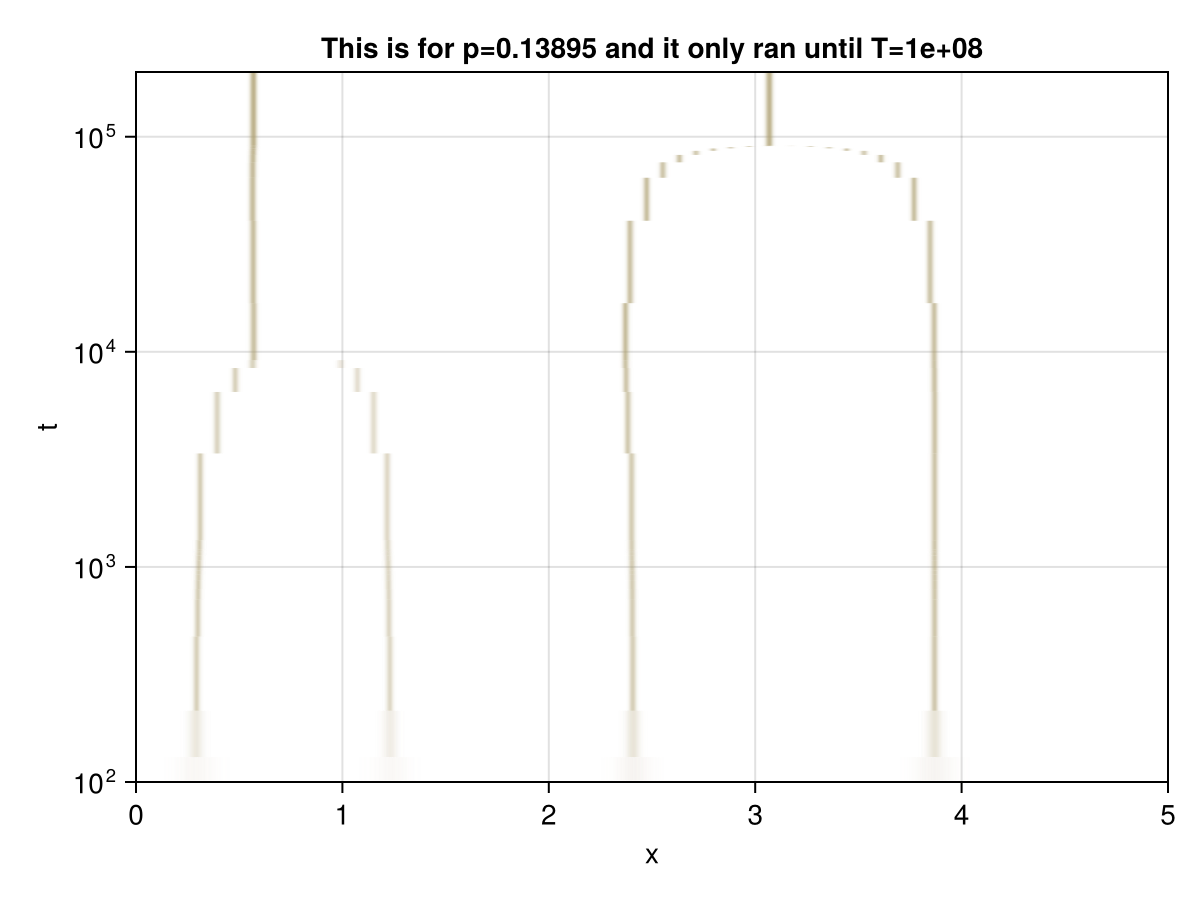

In [354]:
tedges = centres_to_edges_closed(r.sol_ts);
xedges = 0:fmd.dx:fmd.L

fig = Figure()
ax = Axis(fig[1,1];
    title=(@sprintf "This is for p=%.5g and it only ran until T=%.3g" r.ps r.sol_ts[end]),
    xlabel="x",
    ylabel="t",
    yscale=log10
)

heatmap!(ax, xedges, tedges, scaled_cols_mat;
# heatmap!(ax, xedges, tedges, sprel_scaled_cols_mat;
    # colormap=ColorSchemes.Greys,
)

# ylims!(ax, 1e0, tedges[end])
ylims!(ax, 1e2, 2e5)

# display(GLMakie.Screen(), fig)
# Makie.save((@sprintf "spacetime_p%.5f.pdf" r.ps), fig)
fig

## Looking at final states

### Plotting final state abundances accross ps

In [156]:
fs_means = map(df.means) do x x[end][1:N] end;

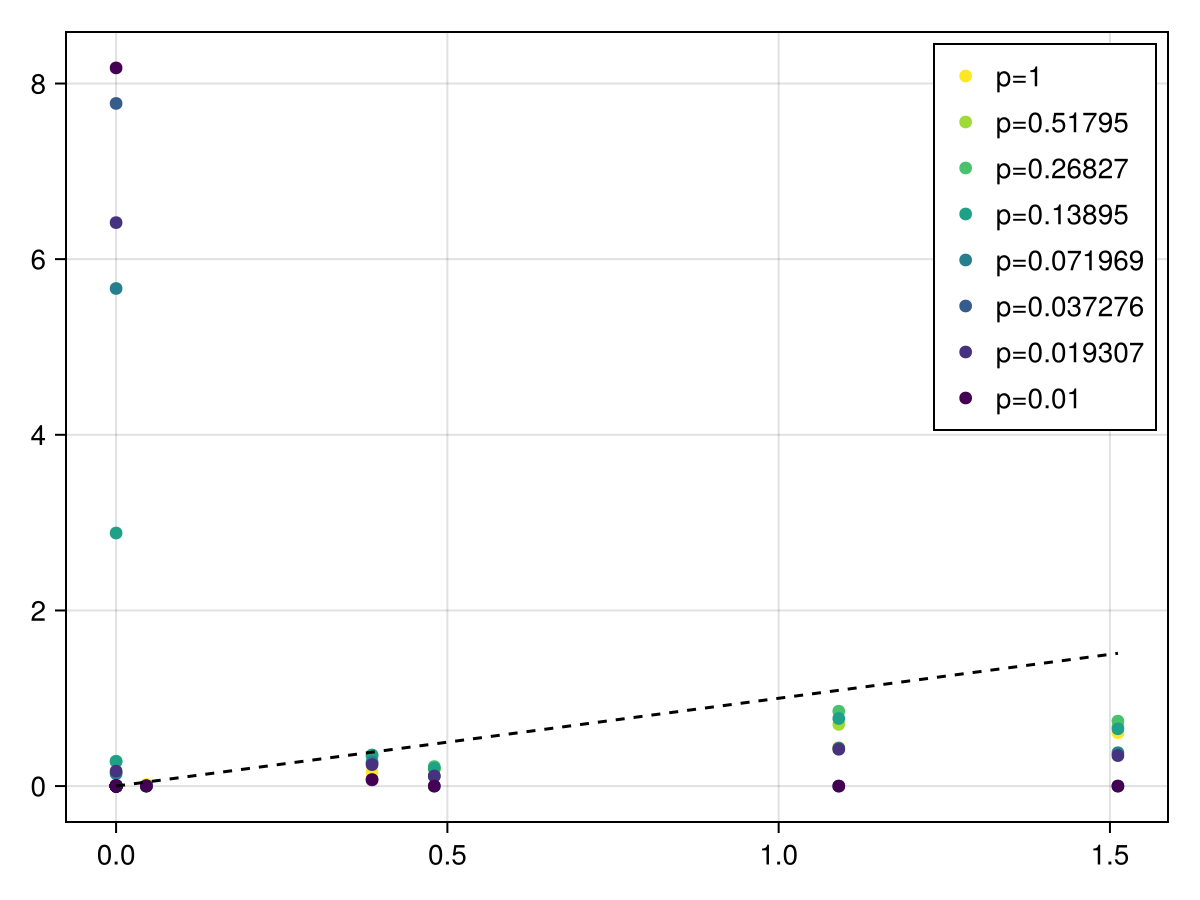

In [277]:
fig = Figure()
ax = Axis(fig[1,1])

logps = log10.(df.ps);
csf = make_scale_func(logps)
for i in 1:nrow(df)
    scatter!(fmd.ode_fs[1:N], fs_means[i];
        label=(@sprintf "p=%.5g" df.ps[i]),
        color=get(ColorSchemes.viridis, csf(logps[i])),
    )
end
axislegend(ax)

lines!(ax, [0., maximum(fmd.ode_fs[1:N])], [0., maximum(fmd.ode_fs[1:N])]; color=:black, linestyle=:dash)

# display(GLMakie.Screen(), fig)

fig

### Looking at the spatial structure

r.fTs = 1.0e8
r.sol_ts[ti] = 1.0e8


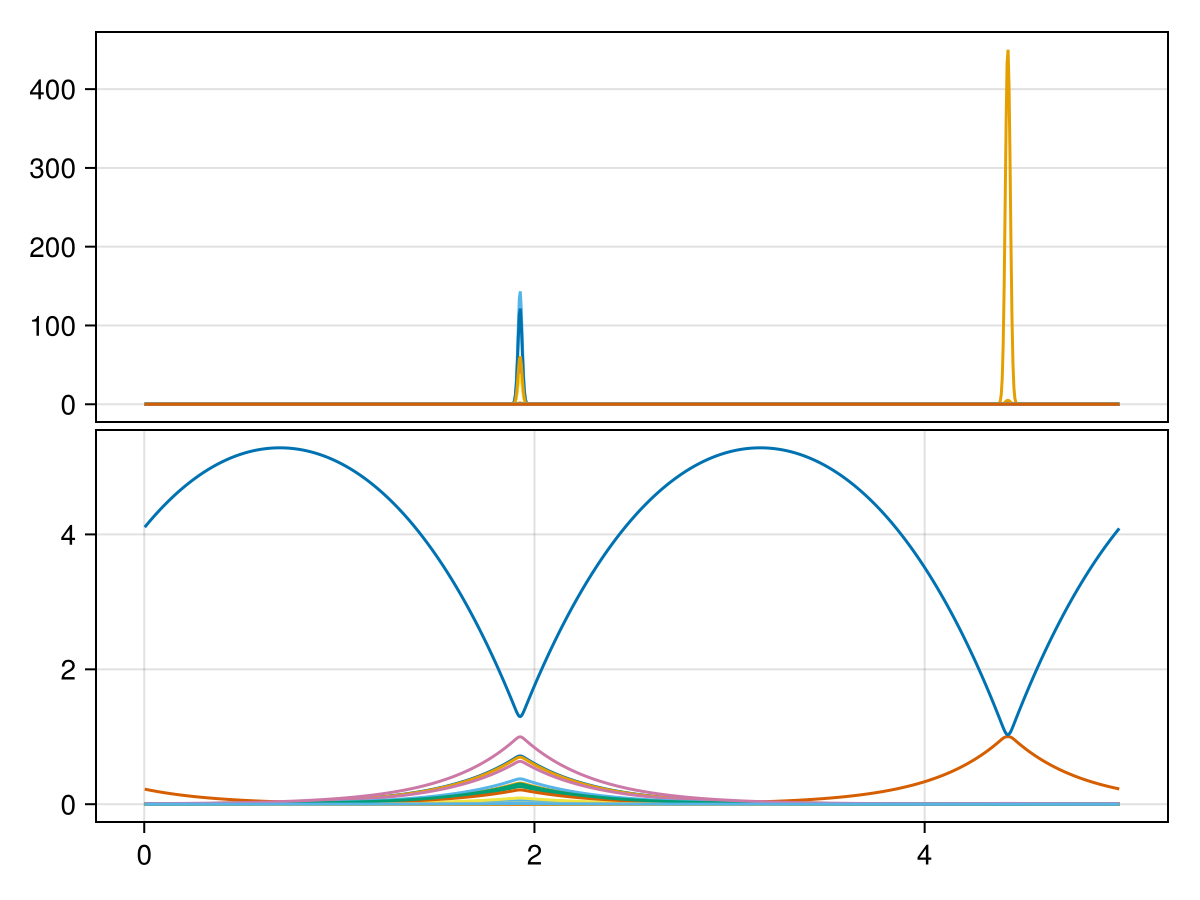

In [419]:
r = df[4,:];
@show r.fTs
# r = df[end-2,:];

ti = 135
@show r.sol_ts[ti]

f = plot_spatial_fs(r.sol_us[ti], N, fmd.sN, fmd.dx)

### Looking at the metabolic networks

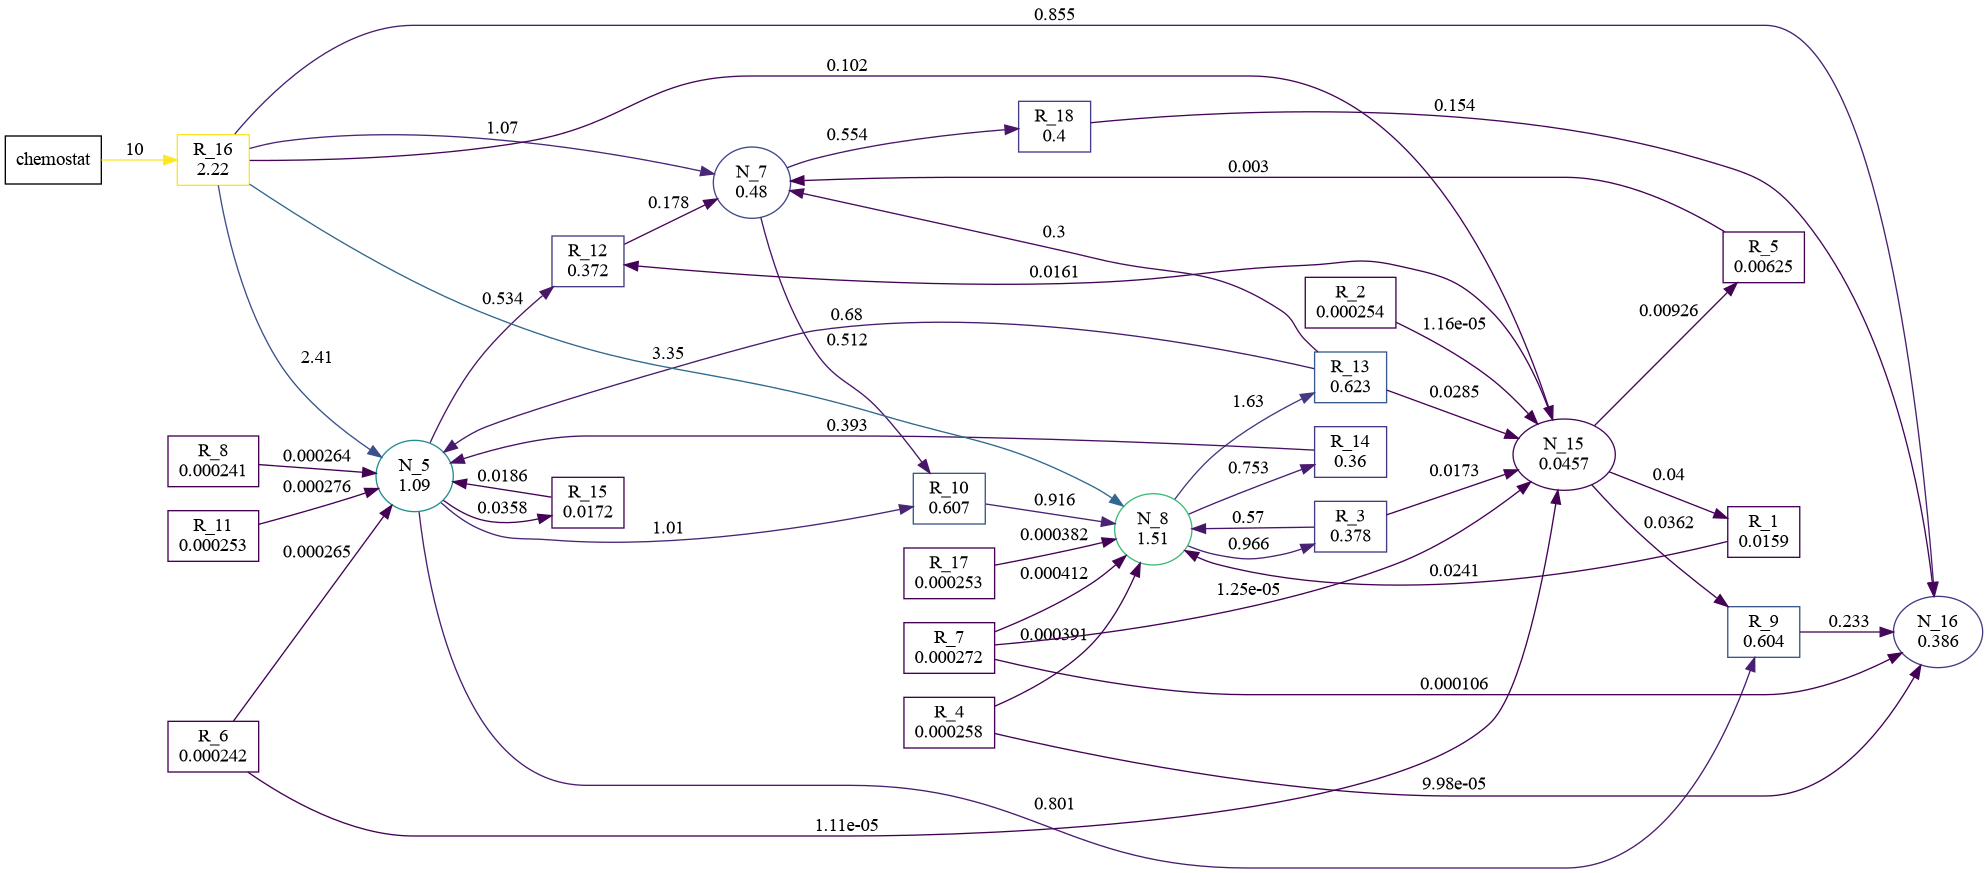

In [355]:
r = df[end,:];

diagram_sfss_v3(r.params, r.means[1];
    strain_threshold=0.01,
    # edge_threshold=0.1,
)

In [333]:
r.params

BSMMiCRMParams{CartesianSpace{1, Tuple{Periodic}, Float64}, Int64, Nothing, Float64}(BMMiCRMParams{Nothing, Float64}([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.9995945362765347, 1.0038566691265014, 0.9993866942839997, 1.0023412632706128, 1.0007982311630996, 0.9996199265231457, 1.001505000085838, 0.9986449734489398, 1.0060649479832042, 1.0006878267014203, 0.9995637246543898, 0.9995547408986384, 1.0012967172759994, 0.9971701660046487, 1.0022974267022788, 1.002730768800976, 1.0016428203485188, 0.99884109482432, 1.0004633541191499, 0.9982418810737196], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 

## Total biomass in time

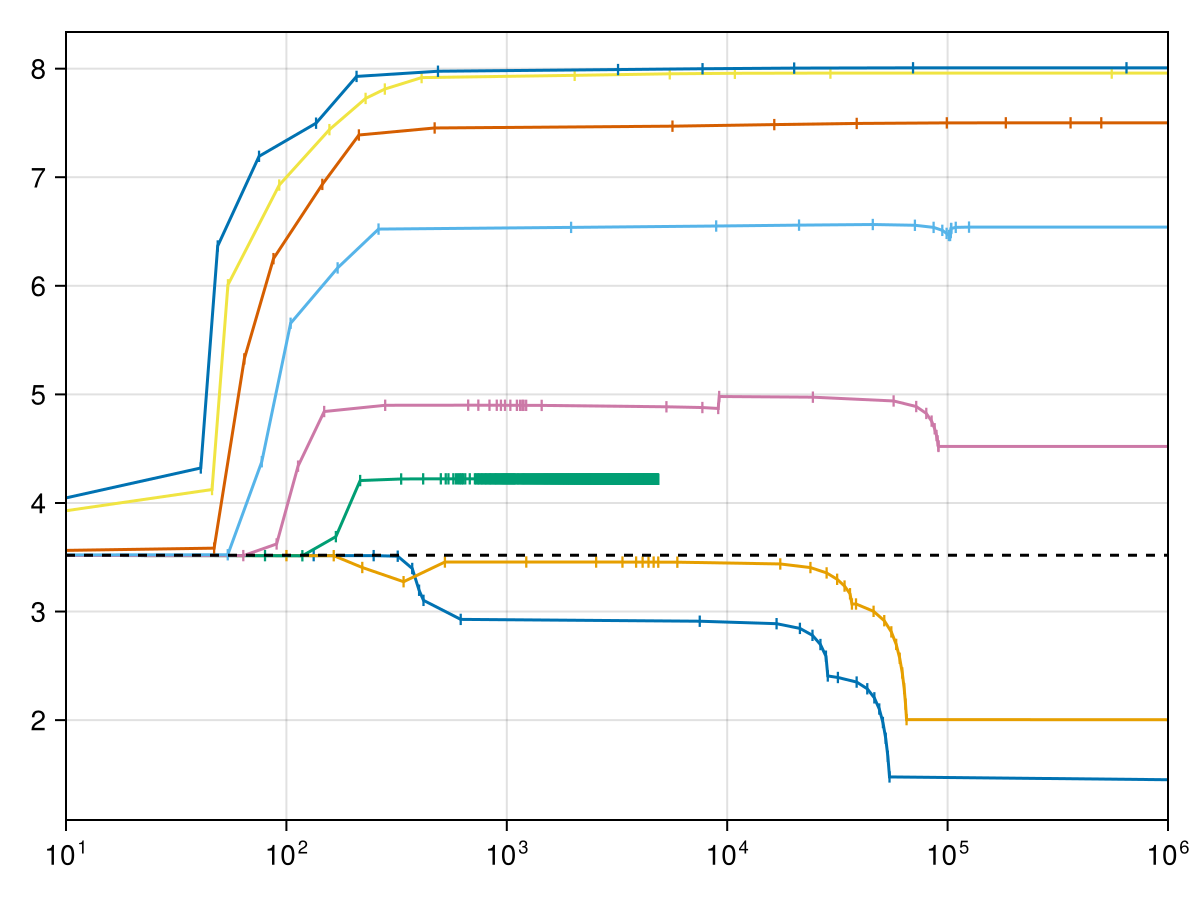

In [312]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)

for r in eachrow(df)
    scatterlines!(ax, r.sol_ts, r.totbioms;
        marker=:vline
    )
end

hlines!(ax, [df.totbioms[1][1]]; color=:black, linestyle=:dash)

# display(GLMakie.Screen(), fig)

xlims!(ax, 1e1, 1e6)
# xlims!(ax, 0., 1e5)

fig

## Plotting community composition

In [313]:
df.commcomps = [map(df.means[i]) do u u[1:N] ./ sum(u[1:N]) end for i in 1:nrow(df)];

### Final accross ps

In [314]:
df.final_comms = [df.means[i][end][1:N] for i in 1:nrow(df)];

In [315]:
sp = sortperm(sum(df.final_comms));

In [316]:
xx = vcat(map(fc -> fc[sp], df.final_comms)...)
strain_is = repeat(1:20, nrow(df));
run_is = vcat([fill(i, 20) for i in 1:nrow(df)]...);

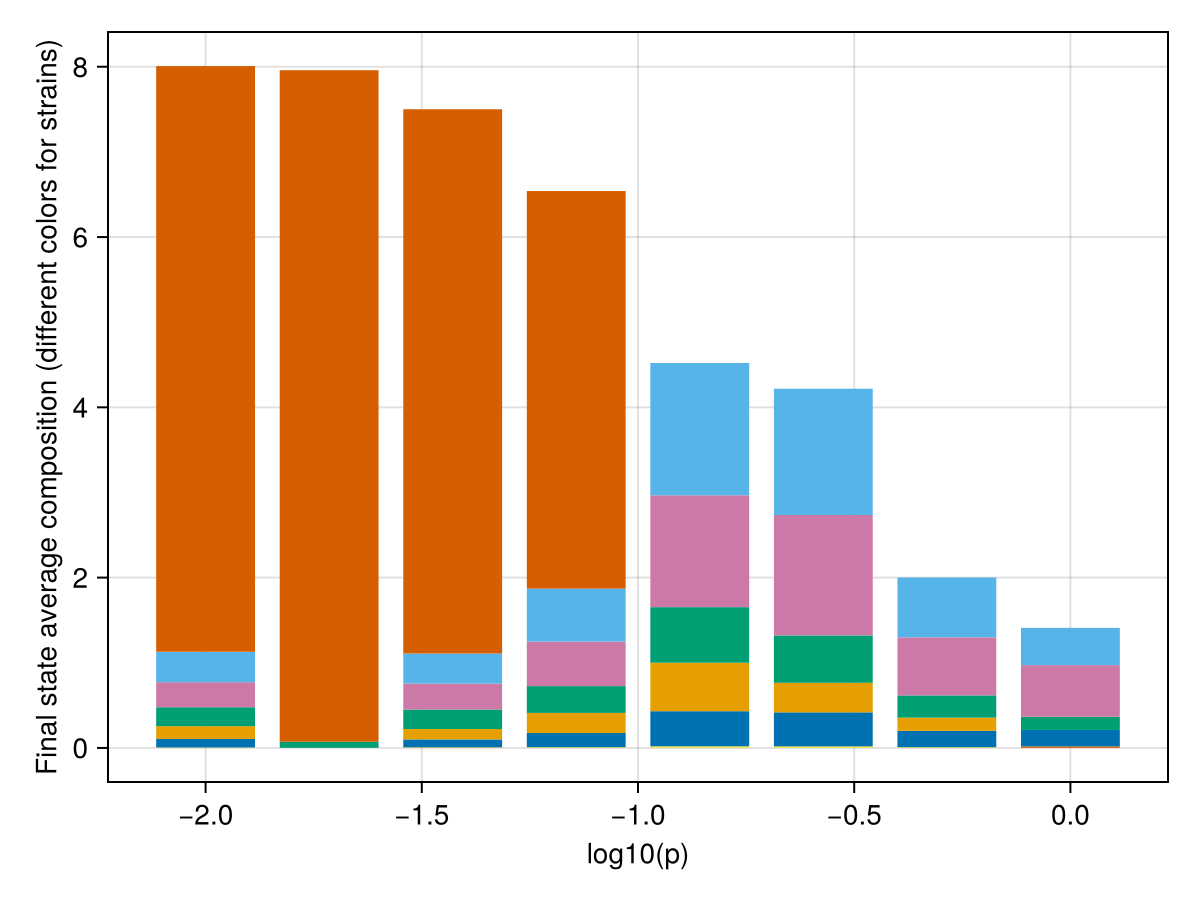

In [317]:
fap = barplot(getindex.(Ref(log10.(df.ps)), run_is), xx;
    stack=strain_is,
    # color=strain_is,
    color=[Makie.wong_colors()[mod1(i, 7)] for i in strain_is],
    axis=(;
        xlabel="log10(p)",
        ylabel="Final state average composition (different colors for strains)",
    )
)

### In time for a single system

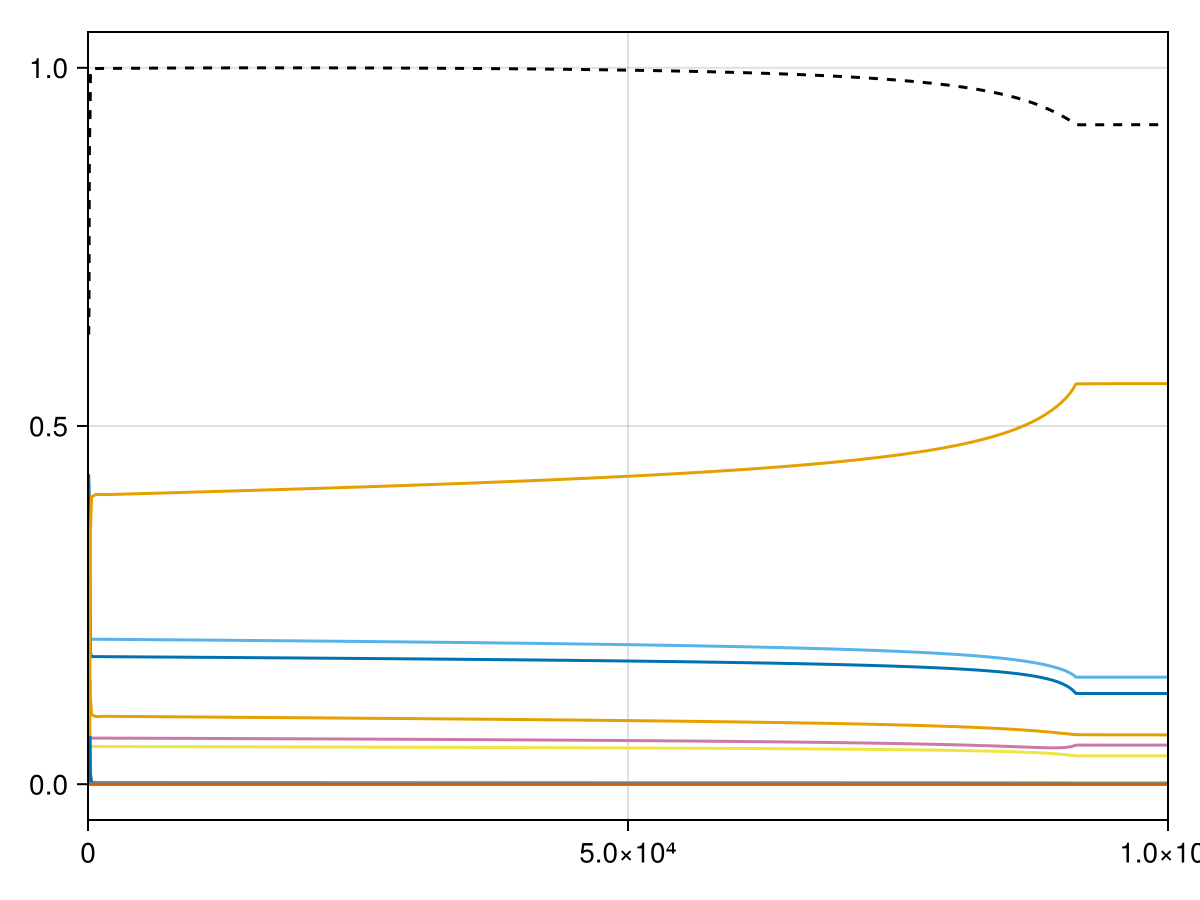

In [43]:
r = df[4,:];

fig = Figure()
ax = Axis(fig[1,1])

for i in 1:N
    lines!(ax, r.sol_ts, getindex.(r.commcomps, i))
end
lines!(ax, r.sol_ts, r.totbioms ./ maximum(r.totbioms);
    color=:black,
    linestyle=:dash,
)

# display(GLMakie.Screen(), fig)

xlims!(ax, 0., 1e5)

fig

### Claude's attempt

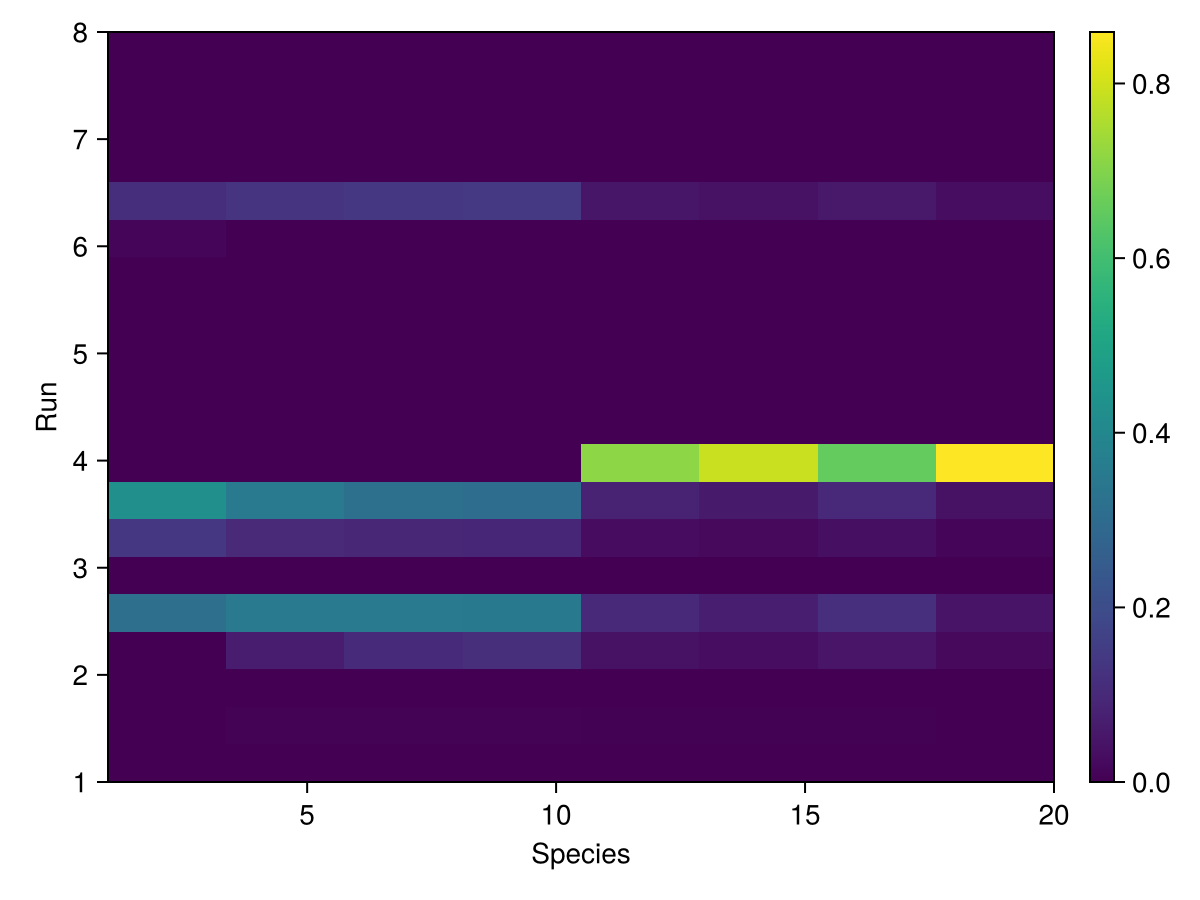

In [17]:
# New plot: heatmap of final relative community composition across runs
nruns = nrow(df)
# each entry of df.commcomps is a vector of length N for each time; take final times
final_comps = [last(df.commcomps[i]) for i in 1:nruns]
# build runs x species matrix: rows=runs, cols=species
comps_mat = permutedims(reduce(hcat, final_comps))
fig = Figure()
ax = Axis(fig[1,1]; xlabel="Species", ylabel="Run")
hm = heatmap!(ax, 1:N, 1:nruns, comps_mat; colormap=:viridis)
Colorbar(fig[1,2], hm)
fig

#### Scatter: strains vs relative abundance across runs
This plot shows each strain on the x-axis and its relative abundance (across runs) on the y-axis.

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/scenes.jl:264


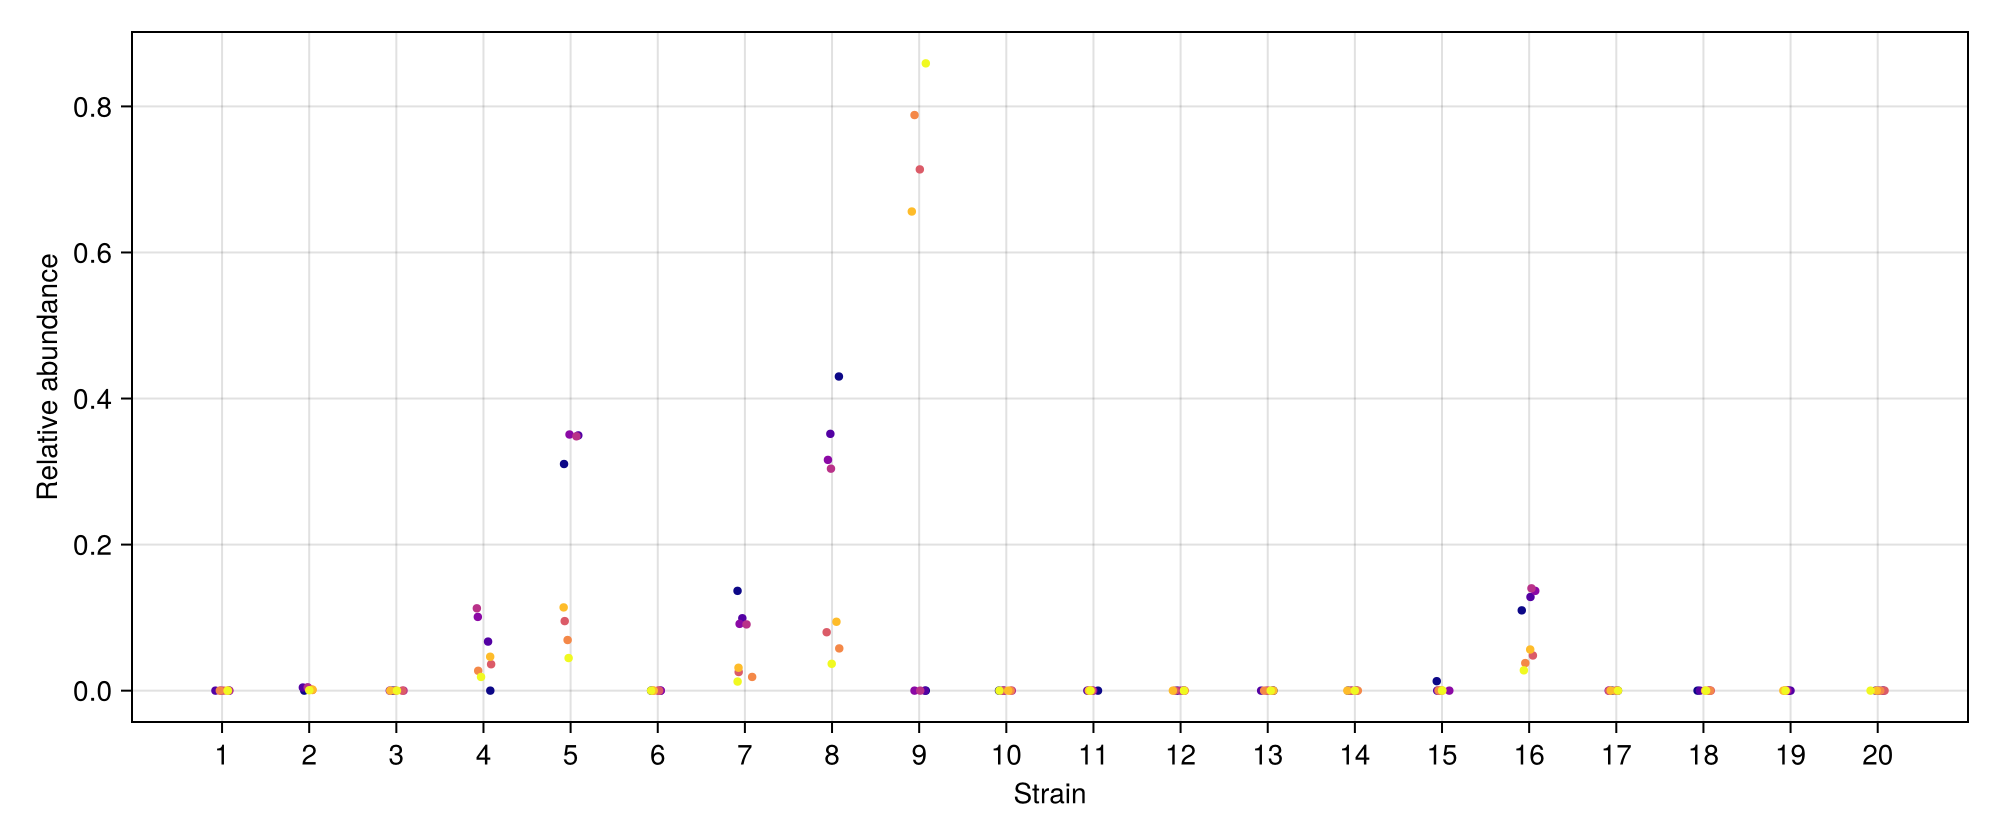

In [ ]:
# Scatter: strains (x) vs relative abundance (y) across runs (points with jitter)
nruns = nrow(df)
final_comps = [last(df.commcomps[i]) for i in 1:nruns]
# rows = runs, cols = species
comps_mat = permutedims(reduce(hcat, final_comps))
# x: strain index repeated for each run, y: corresponding relative abundance
x = repeat(1:N, inner=nruns)
y = vec(comps_mat)
# run index for each point (1..nruns repeated per species)
runs = repeat(1:nruns, outer=N)
# add slight jitter to x to separate overlapping points
xj = x .+ 0.18 .* (rand(length(x)) .- 0.5)
fig = Figure(resolution=(1000,420))
ax = Axis(fig[1,1]; xlabel="Strain", ylabel="Relative abundance")
# color points by run using a colormap
scatter!(ax, xj, y; markersize=6, color=runs, colormap=:plasma)
if N <= 50
    ax.xticks = (1:N, string.(1:N))
end
fig

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/scenes.jl:264


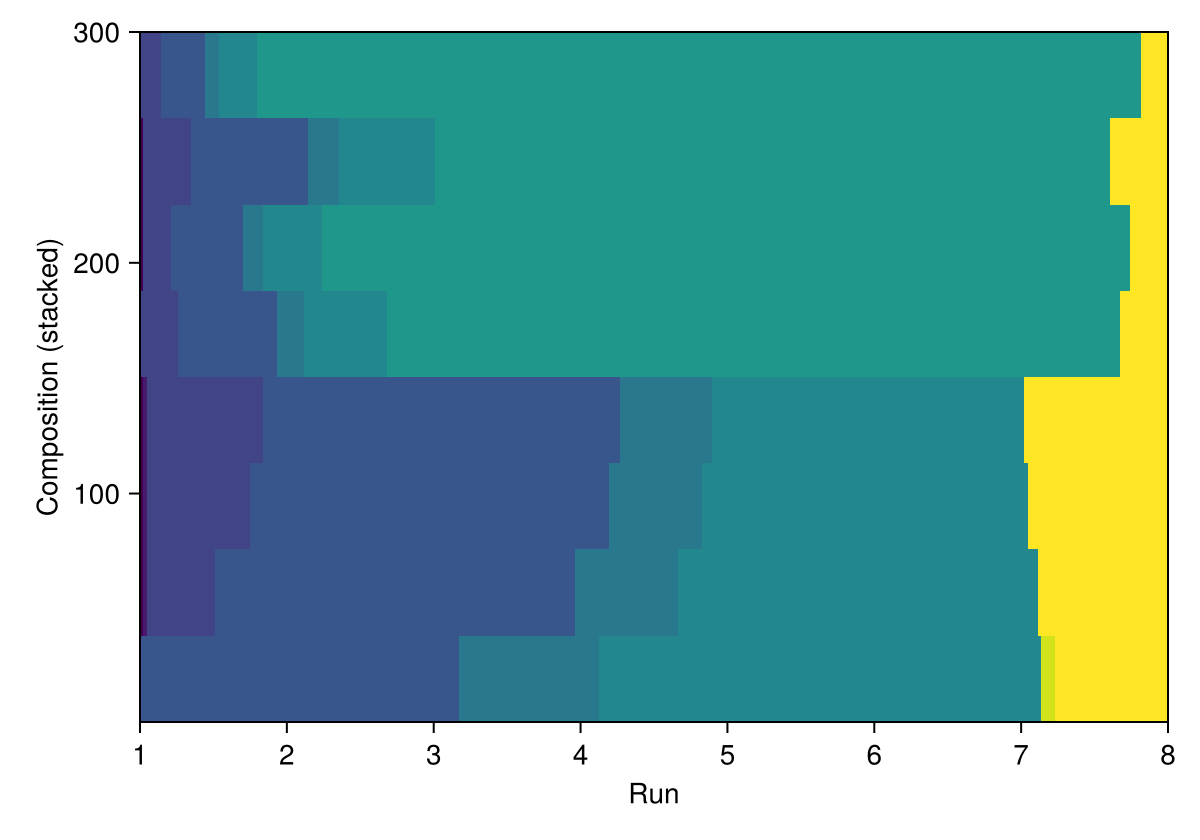

In [22]:
# Stacked-bar-like plot per run using a discrete colour for each strain (rasterized)
nruns = nrow(df)
final_comps = [last(df.commcomps[i]) for i in 1:nruns]
# build runs x species matrix: rows=runs, cols=species
comps_mat = permutedims(reduce(hcat, final_comps))
H = 300  # vertical resolution for each bar (increase for smoother segments)
img = zeros(Int, H, nruns)
for r in 1:nruns
    counts = round.(Int, comps_mat[r, :] * H)
    # ensure counts sum to H
    diff = H - sum(counts)
    if diff > 0
        for k in 1:diff
            counts[mod1(k, N)] += 1
        end
    elseif diff < 0
        for k in 1:-diff
            idx = argmax(counts)
            counts[idx] -= 1
        end
    end
    pos = 1
    for s in 1:N
        if counts[s] > 0
            img[pos:pos+counts[s]-1, r] .= s
            pos += counts[s]
        end
    end
end
# discrete palette for strains (sample from a continuous colormap)
palette = cgrad(:viridis, N)
fig = Figure(resolution=(max(600, 30*nruns), 420))
ax = Axis(fig[1,1]; xlabel="Run", ylabel="Composition (stacked)")
# draw the raster: rows = vertical pixels, cols = runs
hm = heatmap!(ax, 1:nruns, 1:H, img; colormap=palette, interpolate=false)
fig